Libraries loaded.
No CSV found. Generating synthetic dataset.
Data shape: (2000, 17)
Using target column: Loan_Status

Target counts:
 target
1    1152
0     848
Name: count, dtype: int64


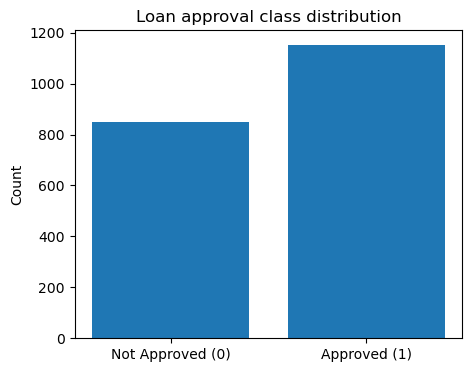

Numeric features used: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'num_1', 'num_2', 'num_3', 'num_4', 'num_5']
Categorical features used: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Credit_History']
Train / test sizes: (1600, 16) (400, 16)
Preprocessor fit complete.
Balanced counts: {1: 922, 0: 678}
Training Logistic Regression...
Training Random Forest...

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.51      0.59      0.55       170
           1       0.66      0.58      0.62       230

    accuracy                           0.59       400
   macro avg       0.59      0.59      0.58       400
weighted avg       0.60      0.59      0.59       400

Confusion Matrix:
 [[101  69]
 [ 96 134]]
ROC AUC: 0.628, AP: 0.702

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.47      0.29      0.36       170
           1 

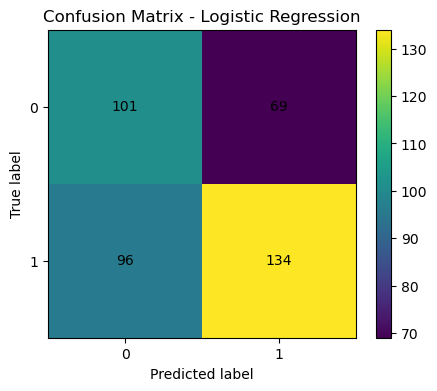

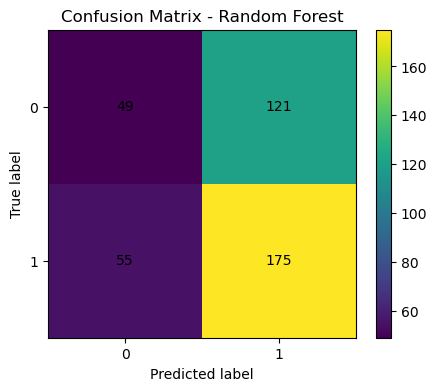

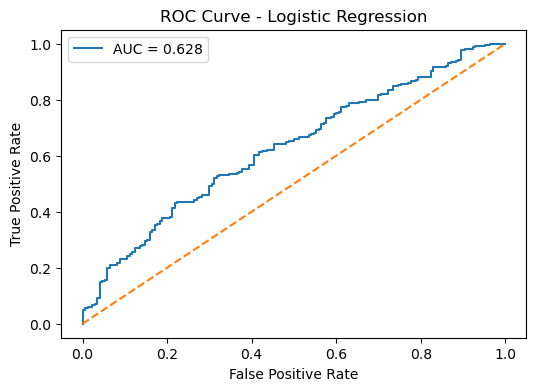

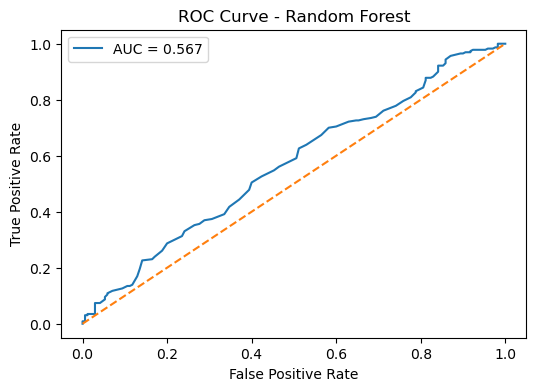

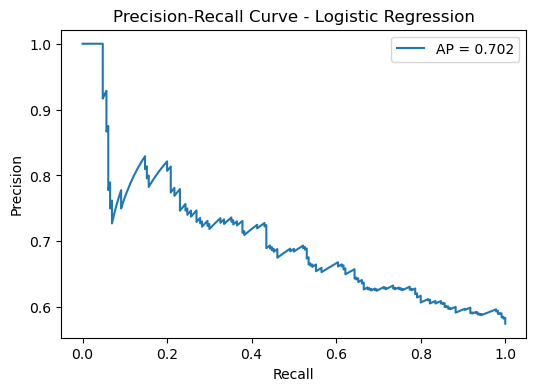

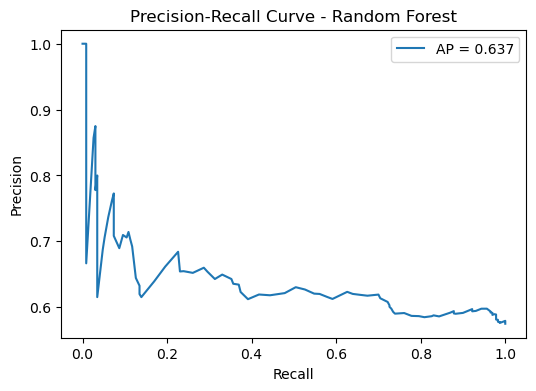

precision: mean=0.619, std=0.007
recall: mean=0.814, std=0.032
f1: mean=0.703, std=0.014
Top feature importances:


,feature,importance
0,ApplicantIncome,0.109730
6,num_3,0.105358
4,num_1,0.100520
2,LoanAmount,0.099297
8,num_5,0.096989
7,num_4,0.096777
5,num_2,0.093395
1,CoapplicantIncome,0.089533
3,Loan_Amount_Term,0.023294
22,Property_Area_Semiurban,0.013387


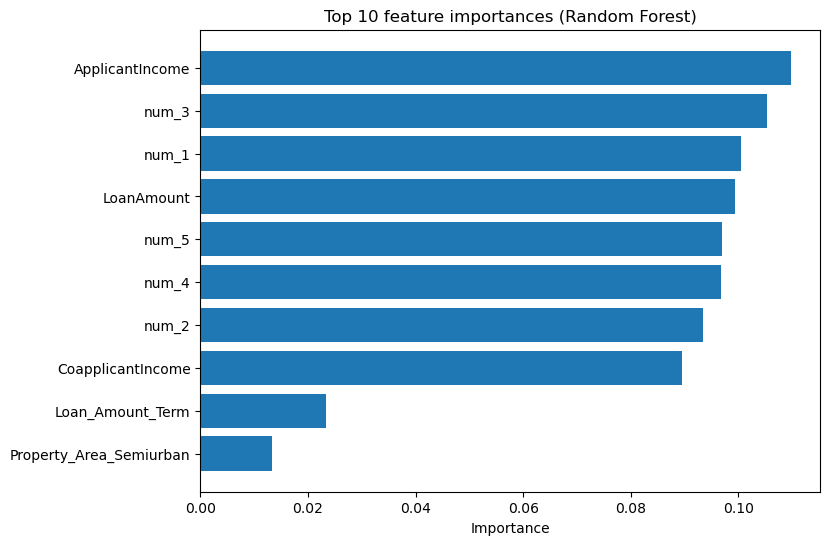

Saved Random Forest pipeline to rf_loan_model.joblib


In [8]:
# Cell 1: Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.utils import resample

print('Libraries loaded.')

# Cell 2: Load dataset or generate synthetic
csv_candidates = ['Loan-Approval-Prediction-Dataset.csv','loan_approval.csv','loan.csv','Loan_Status.csv']
df = None
for fname in csv_candidates:
    if os.path.exists(fname):
        try:
            df = pd.read_csv(fname)
            print(f'Loaded dataset from: {fname}')
            break
        except Exception as e:
            print(f'Found {fname} but failed to load: {e}')

if df is None:
    print('No CSV found. Generating synthetic dataset.')
    from sklearn.datasets import make_classification
    rng = np.random.default_rng(42)
    n = 2000
    X_num, y = make_classification(n_samples=n, n_features=5, n_informative=3, n_redundant=0,
                                   n_clusters_per_class=2, weights=[0.75,0.25], flip_y=0.03, random_state=42)
    df = pd.DataFrame(X_num, columns=[f'num_{i+1}' for i in range(5)])
    df['ApplicantIncome'] = (np.abs(df['num_1']) * 3000 + rng.normal(2000,1000,n)).astype(int)
    df['CoapplicantIncome'] = (np.abs(df['num_2']) * 1500 + rng.normal(500,400,n)).astype(int)
    df['LoanAmount'] = (np.abs(df['num_3']) * 100 + rng.normal(70,20,n)).astype(int)
    df['Loan_Amount_Term'] = rng.choice([360,180,120,240], size=n, p=[0.7,0.15,0.1,0.05])
    df['Credit_History'] = rng.choice([1.0,0.0], size=n, p=[0.85,0.15])
    df['Gender'] = rng.choice(['Male','Female'], size=n, p=[0.7,0.3])
    df['Married'] = rng.choice(['Yes','No'], size=n, p=[0.65,0.35])
    df['Dependents'] = rng.choice(['0','1','2','3+'], size=n, p=[0.5,0.2,0.2,0.1])
    df['Education'] = rng.choice(['Graduate','Not Graduate'], size=n, p=[0.8,0.2])
    df['Self_Employed'] = rng.choice(['Yes','No'], size=n, p=[0.12,0.88])
    df['Property_Area'] = rng.choice(['Urban','Semiurban','Rural'], size=n, p=[0.4,0.35,0.25])
    prob = (0.3 + 0.00004*df['ApplicantIncome'] + 0.2*df['Credit_History'] - 0.001*df['LoanAmount'] + 0.05*(df['Education']=='Graduate').astype(int))
    prob = np.clip(prob, 0.02, 0.98)
    df['Loan_Status'] = [ 'Y' if rng.random() < p else 'N' for p in prob ]
    for col in ['Gender','Married','LoanAmount','Credit_History','Dependents']:
        mask = rng.random(n) < 0.03
        df.loc[mask, col] = np.nan

print('Data shape:', df.shape)
df.head()

# Cell 3: EDA and target processing
target_candidates = ['Loan_Status','LoanStatus','loan_status','target']
target_col = next((c for c in target_candidates if c in df.columns), None)
if target_col is None:
    if 'Loan_Status' in df.columns:
        target_col = 'Loan_Status'
    else:
        raise ValueError('No target column found.')

print('Using target column:', target_col)
df['target'] = df[target_col].map(lambda x: 1 if str(x).strip().upper().startswith('Y') or x==1 else 0)
print('\nTarget counts:\n', df['target'].value_counts())

counts = df['target'].value_counts()
plt.figure(figsize=(5,4))
plt.bar(['Not Approved (0)','Approved (1)'], [counts.get(0,0), counts.get(1,0)])
plt.title('Loan approval class distribution')
plt.ylabel('Count')
plt.show()

# Cell 4: Feature selection and split
possible_numeric = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','num_1','num_2','num_3','num_4','num_5']
numeric_features = [c for c in possible_numeric if c in df.columns]

possible_categorical = ['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Credit_History']
categorical_features = [c for c in possible_categorical if c in df.columns]

print('Numeric features used:', numeric_features)
print('Categorical features used:', categorical_features)

X = df[numeric_features + categorical_features].copy()
y = df['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
print('Train / test sizes:', X_train.shape, X_test.shape)

# Cell 5: Preprocessing and oversampling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # fixed here
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
], remainder='drop')

preprocessor.fit(X_train)
print('Preprocessor fit complete.')

train_df = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
train_df.columns = list(X_train.columns) + ['target']
majority = train_df[train_df['target']==0]
minority = train_df[train_df['target']==1]

if len(minority) / len(majority) < 0.5:
    minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=42)
    train_balanced = pd.concat([majority, minority_upsampled]).sample(frac=1, random_state=42).reset_index(drop=True)
    print('Oversampled minority class.')
else:
    train_balanced = train_df.copy()

print('Balanced counts:', train_balanced['target'].value_counts().to_dict())

X_train_bal = train_balanced[numeric_features + categorical_features]
y_train_bal = train_balanced['target']

# Cell 6: Train models
log_pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('clf', LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42))])

rf_pipe = Pipeline(steps=[('preprocessor', preprocessor),
                          ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42))])

print('Training Logistic Regression...')
log_pipe.fit(X_train_bal, y_train_bal)
print('Training Random Forest...')
rf_pipe.fit(X_train_bal, y_train_bal)

# Cell 7: Evaluate models
models = {'Logistic Regression': log_pipe, 'Random Forest': rf_pipe}
results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    avg_precision = average_precision_score(y_test, y_proba)
    results[name] = {'report': report, 'confusion_matrix': cm, 'roc_auc': roc_auc,
                     'precision_curve': precision, 'recall_curve': recall, 'avg_precision': avg_precision,
                     'fpr': fpr, 'tpr': tpr, 'y_pred': y_pred, 'y_proba': y_proba}
    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred))
    print('Confusion Matrix:\n', cm)
    print(f'ROC AUC: {roc_auc:.3f}, AP: {avg_precision:.3f}')

# Cell 8: Plots (confusion matrices, ROC, Precision-Recall)
for name, res in results.items():
    cm = res['confusion_matrix']
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.xticks([0,1], ['0','1'])
    plt.yticks([0,1], ['0','1'])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, int(cm[i,j]), ha='center', va='center')
    plt.colorbar()
    plt.show()

for name, res in results.items():
    plt.figure(figsize=(6,4))
    plt.plot(res['fpr'], res['tpr'], label=f'AUC = {res["roc_auc"]:.3f}')
    plt.title(f'ROC Curve - {name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.plot([0,1],[0,1], linestyle='--')
    plt.legend()
    plt.show()

for name, res in results.items():
    plt.figure(figsize=(6,4))
    plt.plot(res['recall_curve'], res['precision_curve'], label=f'AP = {res["avg_precision"]:.3f}')
    plt.title(f'Precision-Recall Curve - {name}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.show()

# Cell 9: Cross-validated metrics (n_jobs=1)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['precision', 'recall', 'f1']
for score in scoring:
    cv_scores = cross_val_score(rf_pipe, X, y, cv=skf, scoring=score, n_jobs=1)
    print(f'{score}: mean={cv_scores.mean():.3f}, std={cv_scores.std():.3f}')

# Cell 10: Feature importance
def get_feature_names_from_column_transformer(column_transformer):
    feature_names = []
    for name, trans, cols in column_transformer.transformers_:
        if name == 'remainder': continue
        if hasattr(trans, 'named_steps') and 'onehot' in trans.named_steps:
            ohe = trans.named_steps['onehot']
            cats = ohe.get_feature_names_out(cols)
            feature_names.extend(list(cats))
        else:
            feature_names.extend(cols)
    return feature_names

feature_names = get_feature_names_from_column_transformer(preprocessor)
rf = rf_pipe.named_steps['clf']
importances = rf.feature_importances_
fi = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False).head(20)
print('Top feature importances:')
display(fi)
plt.figure(figsize=(8,6))
topn = fi.head(10)
plt.barh(topn['feature'][::-1], topn['importance'][::-1])
plt.title('Top 10 feature importances (Random Forest)')
plt.xlabel('Importance')
plt.show()

# Cell 11: Save model
import joblib
joblib.dump(rf_pipe, 'rf_loan_model.joblib')
print('Saved Random Forest pipeline to rf_loan_model.joblib')


Libraries loaded successfully.
No CSV found. Generating synthetic dataset...
Data shape: (2000, 17)
Target distribution:
 target
1    1152
0     848
Name: count, dtype: int64
Train/test split complete.
SMOTE applied. New class distribution: [922 922]

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.52      0.59      0.55       170
           1       0.66      0.60      0.63       230

    accuracy                           0.59       400
   macro avg       0.59      0.59      0.59       400
weighted avg       0.60      0.59      0.59       400

ROC AUC: 0.635 | PR AUC: 0.709

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.47      0.45      0.46       170
           1       0.60      0.62      0.61       230

    accuracy                           0.55       400
   macro avg       0.53      0.53      0.53       400
weighted avg       0.55      0.55      0.55       400

ROC AUC: 0.5

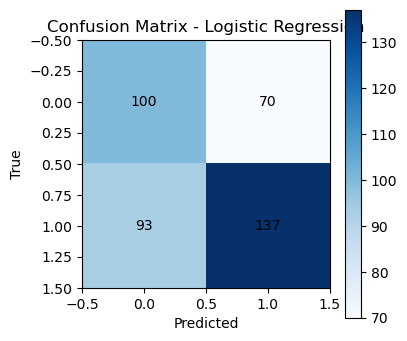

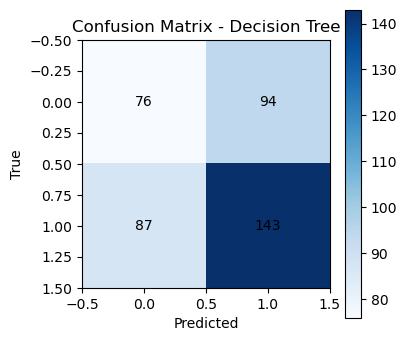

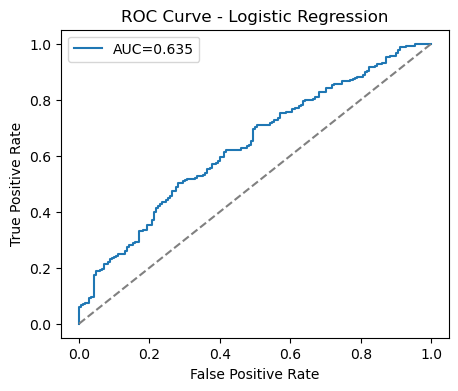

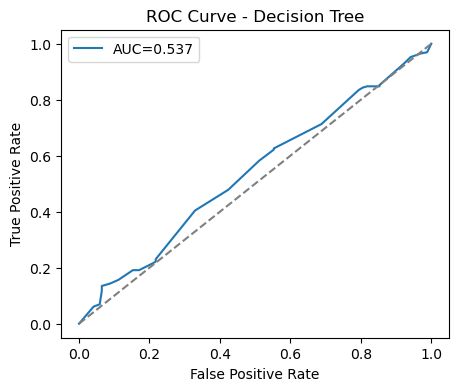

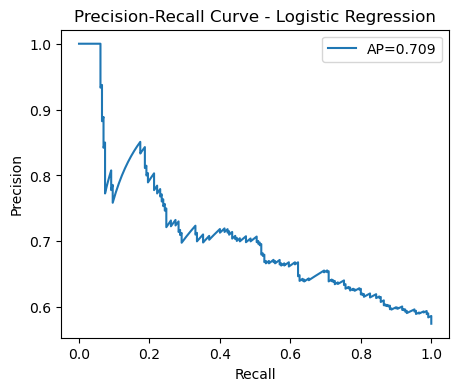

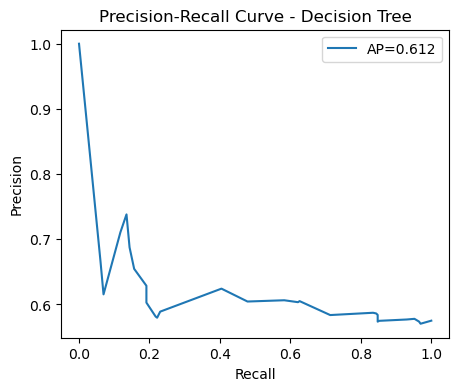

Logistic Regression | Mean F1: 0.599 ± 0.020
Decision Tree | Mean F1: 0.588 ± 0.023


In [9]:
# ===============================
# LOAN APPROVAL PREDICTION (SMOTE + LOGISTIC vs DECISION TREE)
# ===============================

# Cell 1: Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from imblearn.over_sampling import SMOTE

print("Libraries loaded successfully.")

# Cell 2: Load dataset or generate synthetic
csv_candidates = ['Loan-Approval-Prediction-Dataset.csv','loan_approval.csv','loan.csv','Loan_Status.csv']
df = None
for fname in csv_candidates:
    if os.path.exists(fname):
        try:
            df = pd.read_csv(fname)
            print(f"Loaded dataset from: {fname}")
            break
        except Exception as e:
            print(f"Found {fname} but failed to load: {e}")

if df is None:
    print("No CSV found. Generating synthetic dataset...")
    from sklearn.datasets import make_classification
    rng = np.random.default_rng(42)
    n = 2000
    X_num, y = make_classification(n_samples=n, n_features=5, n_informative=3,
                                   n_redundant=0, weights=[0.75, 0.25],
                                   flip_y=0.03, random_state=42)
    df = pd.DataFrame(X_num, columns=[f'num_{i+1}' for i in range(5)])
    df['ApplicantIncome'] = (np.abs(df['num_1']) * 3000 + rng.normal(2000, 1000, n)).astype(int)
    df['CoapplicantIncome'] = (np.abs(df['num_2']) * 1500 + rng.normal(500, 400, n)).astype(int)
    df['LoanAmount'] = (np.abs(df['num_3']) * 100 + rng.normal(70, 20, n)).astype(int)
    df['Loan_Amount_Term'] = rng.choice([360,180,120,240], size=n, p=[0.7,0.15,0.1,0.05])
    df['Credit_History'] = rng.choice([1.0,0.0], size=n, p=[0.85,0.15])
    df['Gender'] = rng.choice(['Male','Female'], size=n, p=[0.7,0.3])
    df['Married'] = rng.choice(['Yes','No'], size=n, p=[0.65,0.35])
    df['Dependents'] = rng.choice(['0','1','2','3+'], size=n, p=[0.5,0.2,0.2,0.1])
    df['Education'] = rng.choice(['Graduate','Not Graduate'], size=n, p=[0.8,0.2])
    df['Self_Employed'] = rng.choice(['Yes','No'], size=n, p=[0.12,0.88])
    df['Property_Area'] = rng.choice(['Urban','Semiurban','Rural'], size=n, p=[0.4,0.35,0.25])
    prob = (0.3 + 0.00004*df['ApplicantIncome'] + 0.2*df['Credit_History'] -
            0.001*df['LoanAmount'] + 0.05*(df['Education']=='Graduate').astype(int))
    prob = np.clip(prob, 0.02, 0.98)
    df['Loan_Status'] = ['Y' if rng.random() < p else 'N' for p in prob]
    for col in ['Gender','Married','LoanAmount','Credit_History','Dependents']:
        mask = rng.random(n) < 0.03
        df.loc[mask, col] = np.nan

print("Data shape:", df.shape)
df.head()

# Cell 3: Define target
df['target'] = df['Loan_Status'].map(lambda x: 1 if str(x).strip().upper().startswith('Y') else 0)
print("Target distribution:\n", df['target'].value_counts())

# Cell 4: Features and train-test split
numeric_features = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']
categorical_features = ['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Credit_History']

X = df[numeric_features + categorical_features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
print("Train/test split complete.")

# Cell 5: Preprocessing and SMOTE
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Apply preprocessing to training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Apply SMOTE for class imbalance
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_processed, y_train)
print("SMOTE applied. New class distribution:", np.bincount(y_train_bal))

# Cell 6: Train models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:,1]
    
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    avg_precision = average_precision_score(y_test, y_proba)
    
    results[name] = {'report': report, 'cm': cm, 'fpr': fpr, 'tpr': tpr,
                     'roc_auc': roc_auc, 'precision': precision,
                     'recall': recall, 'avg_precision': avg_precision}
    
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))
    print(f"ROC AUC: {roc_auc:.3f} | PR AUC: {avg_precision:.3f}")

# Cell 7: Visualization
for name, res in results.items():
    cm = res['cm']
    plt.figure(figsize=(4,4))
    plt.imshow(cm, cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
    plt.colorbar()
    plt.show()

for name, res in results.items():
    plt.figure(figsize=(5,4))
    plt.plot(res['fpr'], res['tpr'], label=f"AUC={res['roc_auc']:.3f}")
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.title(f"ROC Curve - {name}")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()

for name, res in results.items():
    plt.figure(figsize=(5,4))
    plt.plot(res['recall'], res['precision'], label=f"AP={res['avg_precision']:.3f}")
    plt.title(f"Precision-Recall Curve - {name}")
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.show()

# Cell 8: Cross-validation summary
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
    scores = cross_val_score(model, X_train_bal, y_train_bal, cv=skf, scoring='f1', n_jobs=1)
    print(f"{name} | Mean F1: {scores.mean():.3f} ± {scores.std():.3f}")
